# ❤️ Heart Disease Prediction
### A step-by-step ML pipeline with comments and labels

## Step 1 — Import Libraries
Load all required libraries for data manipulation, visualization, and ML modeling.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings for cleaner output

## Step 2 — Load Dataset
Read the heart disease CSV into a DataFrame and preview the first 5 rows.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv')
df.head()  # Preview first 5 rows

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Step 3 — Data Understanding
Explore the dataset structure, dimensions, data types, and summary statistics.

In [3]:
df.columns  # List all column names

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
df.shape  # Returns (rows, columns)

(918, 12)

In [5]:
df.info()  # Data types and non-null counts per column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe()  # Statistical summary: mean, std, min, max, quartiles

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Step 4 — Data Cleaning (Initial Check)
Check for missing values and duplicate rows before any processing.

In [7]:
df.isnull().sum()  # Count missing values per column

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
df.duplicated().sum()  # Count duplicate rows

np.int64(0)

## Step 5 — Exploratory Data Analysis (EDA)
### 5a. Target Variable Distribution
Check class balance — important to detect if the dataset is imbalanced.

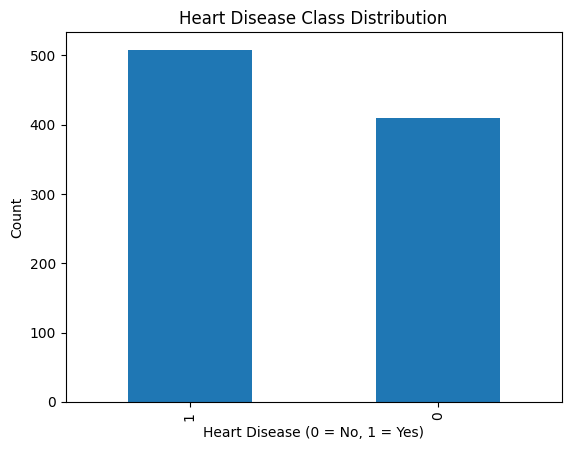

In [9]:
df['HeartDisease'].value_counts().plot(kind='bar')
plt.title('Heart Disease Class Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### 5b. Distribution of Numeric Features (Before Cleaning)
Plot histograms with KDE to spot anomalies like zero values in medical fields.

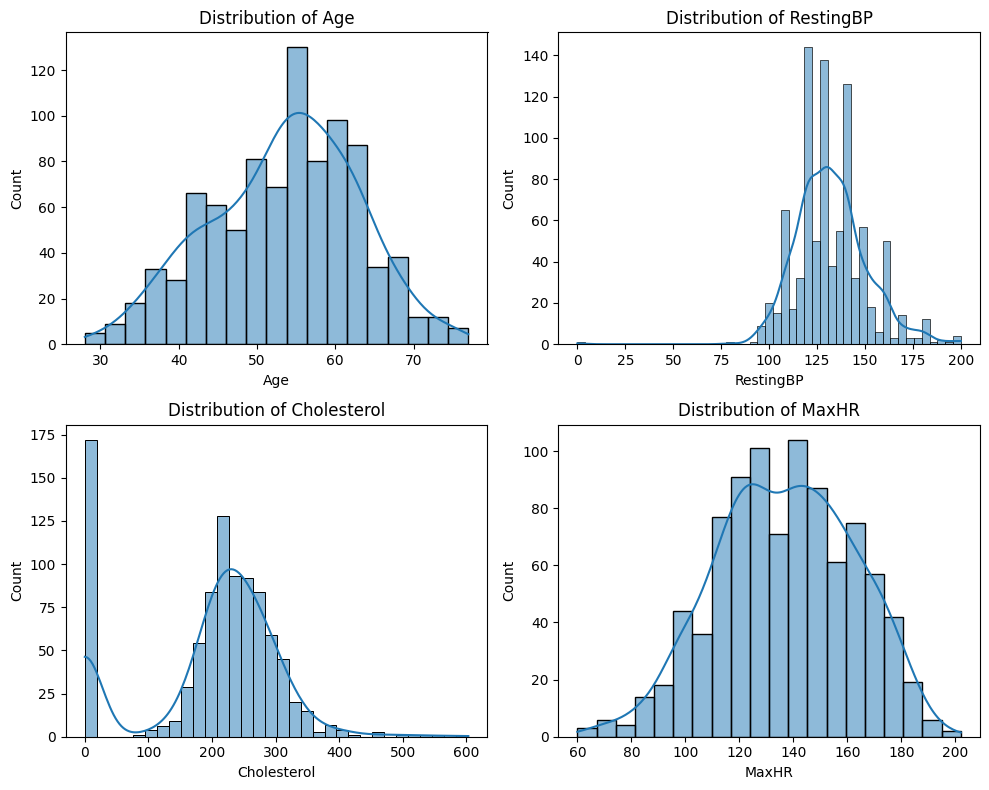

In [10]:
def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var], kde=True)  # KDE curve overlaid on histogram
    plt.title(f'Distribution of {var}')

plt.figure(figsize=(10, 8))
plotting('Age', 1)
plotting('RestingBP', 2)   # May contain 0s — biologically impossible
plotting('Cholesterol', 3) # May contain 0s — biologically impossible
plotting('MaxHR', 4)

plt.tight_layout()
plt.show()

# Observations:
# - RestingBP cannot be 0 (a person would be dead)
# - Cholesterol cannot be 0 (same reason)

## Step 6 — Fix Invalid Zero Values
Replace biologically impossible zero values in `Cholesterol` and `RestingBP` with the mean of valid (non-zero) entries.

In [11]:
# Check how many zeros exist in Cholesterol
df['Cholesterol'].value_counts().head()

Cholesterol
0      172
254     11
220     10
223     10
204      9
Name: count, dtype: int64

In [12]:
# Replace 0 Cholesterol with mean of valid (non-zero) values
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
print(f'Cholesterol mean (non-zero): {ch_mean:.2f}')

df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

Cholesterol mean (non-zero): 244.64


In [13]:
# Replace 0 RestingBP with mean of valid (non-zero) values
resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
print(f'RestingBP mean (non-zero): {resting_bp_mean:.2f}')

df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

RestingBP mean (non-zero): 132.54


### 5c. Re-plot Distributions After Cleaning
Confirm that the zero anomalies have been resolved.

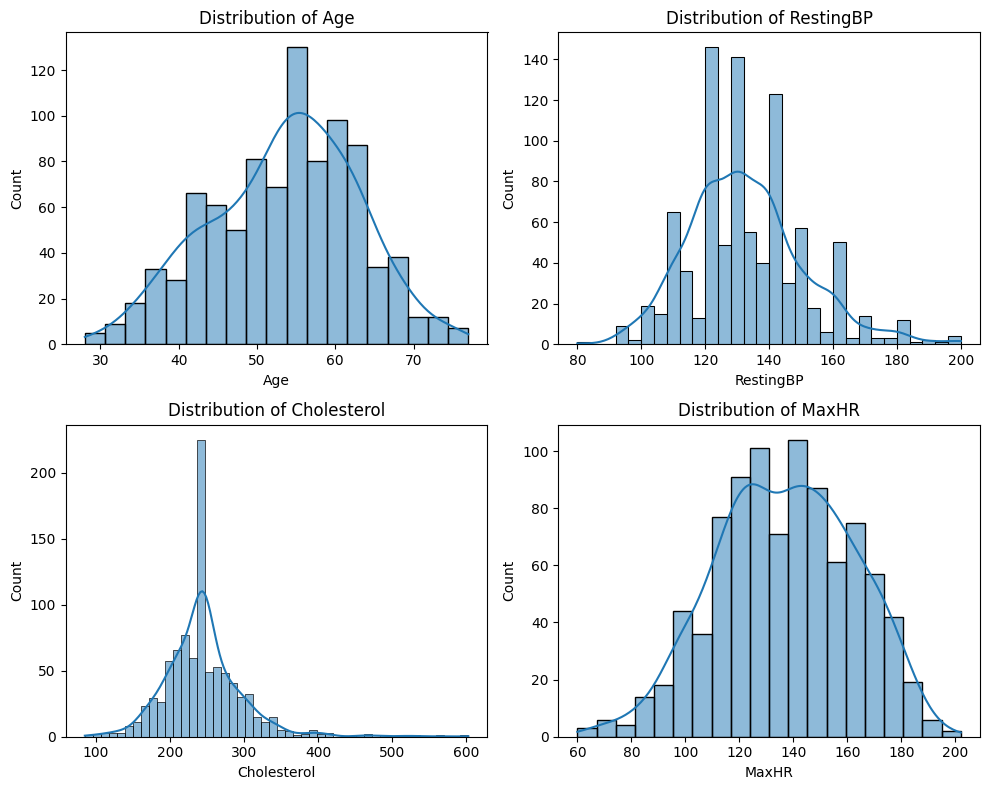

In [14]:
plt.figure(figsize=(10, 8))
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)

plt.tight_layout()
plt.show()

### 5d. Categorical Feature Analysis

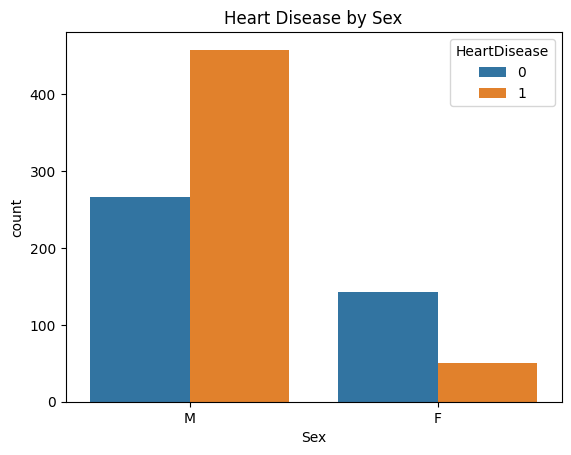

In [15]:
# Heart disease rate by Sex
sns.countplot(x='Sex', hue='HeartDisease', data=df)
plt.title('Heart Disease by Sex')
plt.show()

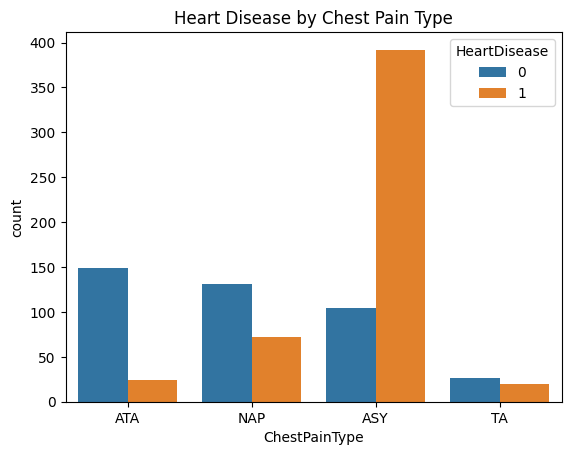

In [16]:
# ASY (Asymptomatic) chest pain has the highest association with heart disease
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)
plt.title('Heart Disease by Chest Pain Type')
plt.show()

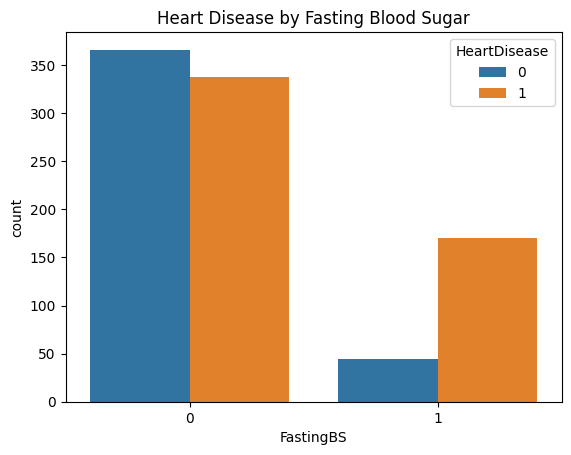

In [17]:
# Fasting blood sugar > 120 mg/dL (1) shows higher heart disease rate
sns.countplot(x='FastingBS', hue='HeartDisease', data=df)
plt.title('Heart Disease by Fasting Blood Sugar')
plt.show()

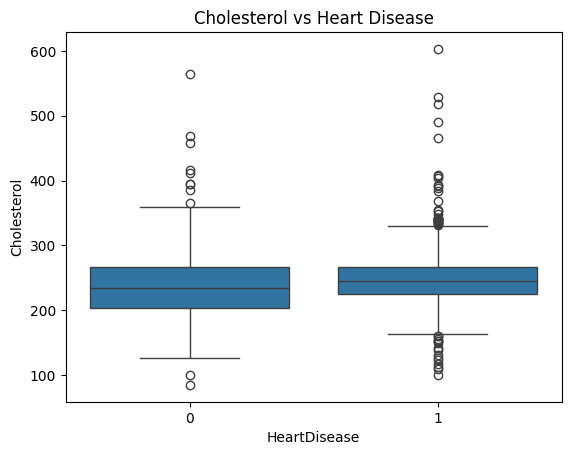

In [18]:
# Compare cholesterol spread between disease groups
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df)
plt.title('Cholesterol vs Heart Disease')
plt.show()

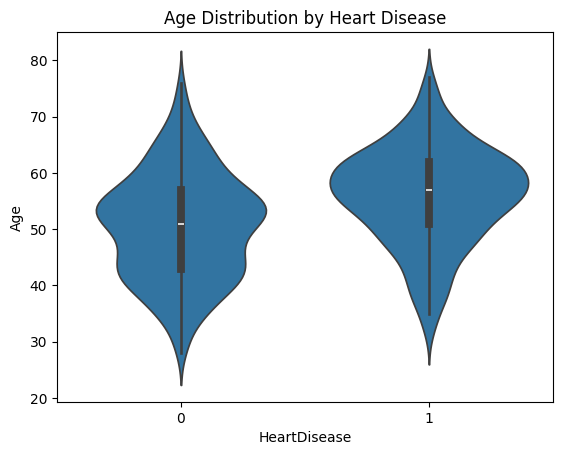

In [19]:
# Age distribution for diseased vs non-diseased patients
sns.violinplot(x='HeartDisease', y='Age', data=df)
plt.title('Age Distribution by Heart Disease')
plt.show()

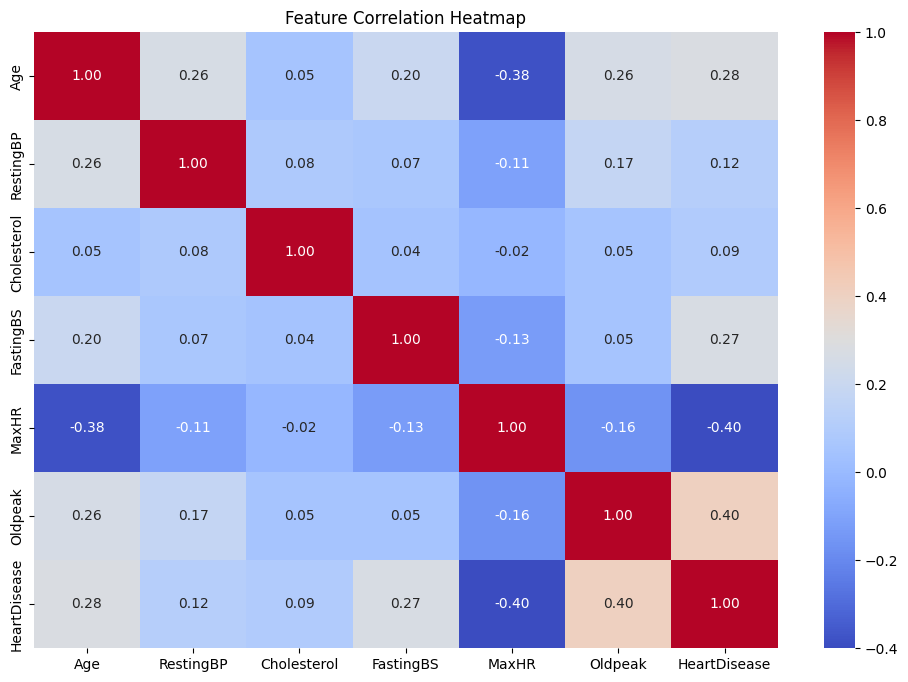

In [20]:
# Correlation heatmap — identify features most correlated with HeartDisease
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Step 7 — Data Preprocessing
Encode categorical variables and convert all columns to integers for ML compatibility.

In [21]:
# One-hot encode categorical columns
# drop_first=True avoids the dummy variable trap (multicollinearity)
df_encode = pd.get_dummies(df, drop_first=True)
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [22]:
# Convert all boolean columns (True/False) to integers (1/0)
df_encode = df_encode.astype(int)
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [23]:
df_encode.columns  # Verify final encoded column names

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

## Step 8 — Import ML Libraries
Load scikit-learn modules for splitting, scaling, and model training.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

## Step 9 — Feature / Target Split & Train-Test Split
Separate features (X) from the target (y), then split into 80% train / 20% test.

In [25]:
X = df_encode.drop('HeartDisease', axis=1)  # All columns except target
y = df_encode['HeartDisease']               # Target variable (0 = No disease, 1 = Disease)

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')

Features shape: (918, 15)
Target shape:   (918,)


In [26]:
# 80% training data, 20% test data
# random_state=42 ensures reproducibility across runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 734 samples
Test set:     184 samples


## Step 10 — Feature Scaling
Standardize features to zero mean and unit variance.

> ⚠️ **Bug Fix Applied:** The original code used `fit_transform` on `X_test`, which re-fits the scaler on test data (data leakage). Corrected to use `transform` only.

In [27]:
scalar = StandardScaler()

# Fit the scaler on TRAINING data only, then transform
X_train_scaled = scalar.fit_transform(X_train)

# BUG FIX: Use .transform() (not .fit_transform()) on test data
# This ensures test data is scaled using the same parameters as training data
X_test_scaled = scalar.transform(X_test)  # FIXED (was: scalar.fit_transform(X_test))

## Step 11 — Define & Train Multiple Models
Train 5 different classifiers and compare their performance using Accuracy and F1 Score.

In [28]:
models = {
    'Logistic Regression':        LogisticRegression(),
    'K-Nearest Neighbors':        KNeighborsClassifier(),
    'Naive Bayes':                GaussianNB(),
    'Decision Tree':              DecisionTreeClassifier(),
    'Support Vector Machine (RBF)': SVC(probability=True),
}

In [29]:
result = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)        # Train on scaled training data
    y_pred = model.predict(X_test_scaled)     # Predict on scaled test data
    accuracy = accuracy_score(y_test, y_pred) # Overall correct predictions
    f1 = f1_score(y_test, y_pred)             # Harmonic mean of precision & recall
    result.append({'Model': name, 'Accuracy': round(accuracy, 4), 'F1_score': round(f1, 4)})

# Display results as a DataFrame for easy comparison
results_df = pd.DataFrame(result).sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

                       Model  Accuracy  F1_score
         Logistic Regression    0.8696    0.8846
         K-Nearest Neighbors    0.8641    0.8815
                 Naive Bayes    0.8478    0.8614
Support Vector Machine (RBF)    0.8478    0.8667
               Decision Tree    0.7880    0.8040


### 11a. Detailed Classification Report for Best Model

In [30]:
# Print full precision, recall, F1 breakdown for Logistic Regression
# (classification_report was imported but never used in the original notebook)
y_pred_lr = models['Logistic Regression'].predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        77
     Disease       0.91      0.86      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



## Step 12 — Save Model, Scaler & Feature Columns
Persist the trained model and preprocessing artifacts for deployment or inference.

In [31]:
import joblib

joblib.dump(models['Logistic Regression'], 'Logistic_heart.pkl')  # Save trained model
joblib.dump(scalar, 'scalar.pkl')                                 # Save scaler (needed to scale new input at inference)
joblib.dump(X.columns.tolist(), 'columns.pkl')                    # Save feature names (for input validation)

print('Model, scaler, and columns saved successfully.')

Model, scaler, and columns saved successfully.
